# Thickness-signal audit

**Question.** The earlier result said a photo cannot predict absolute sample
height once the substrate tilt is removed from the labels. Was that a real limit
or an artifact of how the features were built?

Three candidate artifacts, plus one that emerged from the results:

1. **Diluted features** — statistics averaged over a whole 267 µm cell when the
   pad is far smaller.
2. **Crop tightness** — the deck found tighter crops *hurt*, but measured that
   on tilt-contaminated labels where context also encodes position.
3. **Label noise** — `h_max` is one pixel standing in for a ~1 µm quantity.
4. **What is DINOv2 seeing?** — brightness finds ρ ≈ 0.05, DINOv2 finds ρ ≈ 0.43.

Run top to bottom. Everything is read from `results/`, produced by the scripts
in `src/`.

In [1]:
%matplotlib inline

import csv
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

AUDIT = Path.cwd()
while AUDIT != AUDIT.parent and not (AUDIT / "results").is_dir():
    AUDIT = AUDIT.parent
REPO = AUDIT.parent.parent
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(AUDIT / "src"))
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

BRIGHT, DINO, CTRL = "#2a78d6", "#eb6834", "#1baf7a"
NOISE_FLOOR = 0.10

def read(name):
    return list(csv.DictReader((AUDIT / "results" / name).open()))

cells = read("cells_audit.csv")
ev    = read("evaluation.csv")
pc    = read("position_control.csv")
pr    = read("position_recovery.csv")
print(f"cells {len(cells)} · plates {len({r['plate'] for r in cells})}")

cells 4416 · plates 69


## 1. How much of a cell is actually polymer?

The concern was that averaging over a full-pitch cell drowns the pad in bare
silicon. First, quantify it.

pad / cell area:  mean 3.9%   median 4.0%
=> brightness statistics over a whole cell are ~96% substrate

the concern was well-founded. whether fixing it helps is section 2.


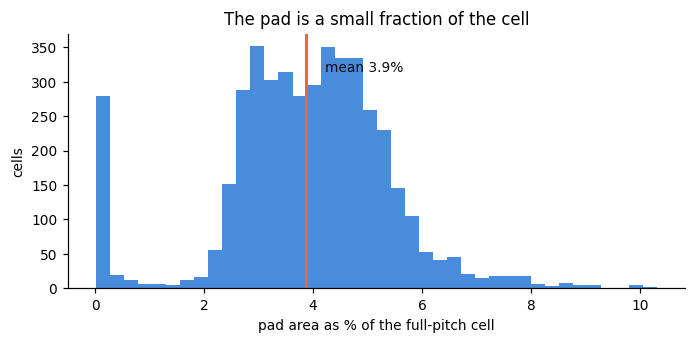

In [2]:
pf = np.array([float(r["pad_frac"]) for r in cells
               if r.get("pad_frac") not in (None, "", "nan")])
print(f"pad / cell area:  mean {pf.mean()*100:.1f}%   median {np.median(pf)*100:.1f}%")
print(f"=> brightness statistics over a whole cell are ~{(1-pf.mean())*100:.0f}% substrate")
print(f"\nthe concern was well-founded. whether fixing it helps is section 2.")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(pf * 100, bins=40, color=BRIGHT, alpha=0.85)
ax.axvline(pf.mean() * 100, color=DINO, lw=2)
ax.text(pf.mean() * 100 + 0.35, ax.get_ylim()[1] * 0.85,
        f"mean {pf.mean()*100:.1f}%", color="#0b0b0b", fontsize=9)
ax.set_xlabel("pad area as % of the full-pitch cell")
ax.set_ylabel("cells")
ax.set_title("The pad is a small fraction of the cell")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()

## 2. Experiments 1 & 2 — does concentrating on the pad help?

Sweep the feature window from the full pitch down to the pad footprint, plus a
data-driven pad mask and a **substrate-ring control** (silicon immediately around
the pad, pad excluded).

The ring is the important one. If bare substrate beside the pad predicts height
as well as the pad does, then whatever signal exists is **not** the pad's
absorption — which rules out the physical mechanism, not just one implementation.

In [3]:
reg = [(r["config"], float(r["median_r2"]), float(r["spearman"]))
       for r in ev if r["experiment"] == "feature_region"]
print(f"{'feature region':30} {'median R2':>10} {'Spearman':>10}")
for nm, r2v, rho in reg:
    flag = "   <- control" if "ring" in nm else ""
    print(f"{nm:30} {r2v:10.3f} {rho:10.3f}{flag}")

best = max((r for r in reg if "ring" not in r[0]), key=lambda t: t[2])
print(f"\nbest non-control region: {best[0]}  (rho {best[2]:+.3f})")
print(f"substrate-ring control : {[r for r in reg if 'ring' in r[0]][0][2]:+.3f}")
print("\nEvery value is inside the +/-0.10 band that brightness reaches by chance.")

feature region                  median R2   Spearman
window 267 um                      -0.148      0.052
window 200 um                      -0.154      0.026
window 150 um                      -0.160      0.038
window 110 um                      -0.160     -0.011
window 80 um                       -0.173     -0.129
window 60 um                       -0.184     -0.115
pad mask (data-driven)             -0.188     -0.030
ring around pad (control)          -0.192      0.071   <- control
sharpness / focus                  -0.166     -0.090
brightness + sharpness             -0.168     -0.056

best non-control region: window 267 um  (rho +0.052)
substrate-ring control : +0.071

Every value is inside the +/-0.10 band that brightness reaches by chance.


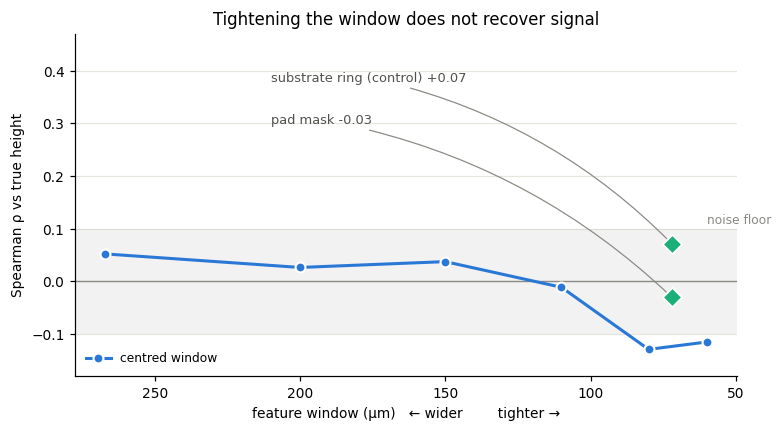

In [4]:
wins = [267, 200, 150, 110, 80, 60]
d = dict((nm, rho) for nm, _, rho in reg)
ys = [d.get(f"window {w} um", np.nan) for w in wins]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.axhspan(-NOISE_FLOOR, NOISE_FLOOR, color="#8a8983", alpha=0.10, lw=0)
ax.axhline(0, color="#8a8983", lw=0.9)
ax.plot(wins, ys, color=BRIGHT, lw=2, marker="o", ms=6.5, mec="white", mew=1.4,
        label="centred window")
for nm, key in (("pad mask", "pad mask (data-driven)"),
                ("substrate ring (control)", "ring around pad (control)")):
    if key in d:
        ax.scatter([72], [d[key]], color=CTRL, s=80, marker="D",
                   edgecolors="white", linewidths=1.2, zorder=4)
        ax.annotate(f"{nm} {d[key]:+.2f}", xy=(72, d[key]), xytext=(210, 0.30
                    if "pad" in nm else 0.38), fontsize=8.5, color="#52514e",
                    arrowprops=dict(arrowstyle="-", color="#8a8983", lw=0.8,
                                    connectionstyle="arc3,rad=-0.15"))
ax.text(60, NOISE_FLOOR + 0.01, "noise floor", fontsize=8, color="#8a8983")
ax.invert_xaxis()
ax.set_ylim(-0.18, 0.47)
ax.set_xlabel("feature window (µm)   ← wider        tighter →")
ax.set_ylabel("Spearman ρ vs true height")
ax.set_title("Tightening the window does not recover signal")
ax.legend(fontsize=8, frameon=False, loc="lower left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e5e0", lw=0.8)
ax.set_axisbelow(True)
fig.tight_layout()

### The focus hypothesis, tested

Brightness finds nothing yet DINOv2 finds something, so the cue must be
*structural*. One physically plausible candidate: the lens has a very shallow
depth of field, so a taller pad sits closer to the focal plane and might render
sharper — depth-from-focus happening by accident in a single frame.

Seven sharpness measures were computed (Laplacian variance, Sobel magnitude,
difference-of-Gaussian energy ratio) to test it.

In [5]:
for nm, r2v, rho in reg:
    if "sharp" in nm.lower() or "+" in nm:
        print(f"{nm:30} median R2 {r2v:+.3f}   Spearman {rho:+.3f}")
print("\nNo signal. Hand-crafted sharpness is not the cue.")
print("This does NOT rule out a deliberate z-stack, where the focus difference")
print("would be driven, large, and measured on purpose.")

sharpness / focus              median R2 -0.166   Spearman -0.090
brightness + sharpness         median R2 -0.168   Spearman -0.056

No signal. Hand-crafted sharpness is not the cue.
This does NOT rule out a deliberate z-stack, where the focus difference
would be driven, large, and measured on purpose.


## 3. Experiment 3 — is the label too noisy?

`h_max` is a single pixel. Compare against percentile and pad-mean variants.
"Roughness" is a proxy: the median absolute difference between a cell and its
four grid neighbours. Neighbours are different formulations so it is not pure
noise, but it is measured identically across variants.

In [6]:
print(f"{'label':28} {'median R2':>10} {'Spearman':>10}")
for r in ev:
    if r["experiment"] == "label":
        print(f"{r['config']:28} {float(r['median_r2']):10.3f} "
              f"{float(r['spearman']):10.3f}")
print("\nThe spread across all four is smaller than the noise.")
print("Label noise is not the bottleneck.")

label                         median R2   Spearman
h_max (previous choice)          -0.148      0.052
h_p95                            -0.144      0.057
h_p99                            -0.148      0.048
h_maskmean                       -0.154      0.028

The spread across all four is smaller than the noise.
Label noise is not the bottleneck.


## 4. Experiment 4 — is DINOv2 reading thickness, or position?

This is the finding that changes the interpretation.

Even after detrending, the corrected label still correlates with `(row, col)`,
because the formulation layout is systematic. And illumination varies smoothly
across the plate. So a high-capacity extractor can infer *where* a cell is — and
knowing where partly tells you how thick, without measuring thickness.

**Step 1:** can the features recover a cell's grid index, on held-out plates?

In [7]:
print(f"{'features':26} {'-> row':>10} {'-> column':>11}")
for r in pr:
    print(f"{r['features']:26} {float(r['row_rho']):10.3f} "
          f"{float(r['col_rho']):11.3f}")
print("\nDINOv2 recovers a cell's coordinates almost perfectly from the photo.")
print("That is the illumination field.")

features                       -> row   -> column
brightness (7)                  0.905       0.096
DINOv2 (768)                    0.932       0.858

DINOv2 recovers a cell's coordinates almost perfectly from the photo.
That is the illumination field.


**Step 2:** subtract each plate's own `(row, col)` linear trend from the label,
leaving only variation that is independent of where a cell sits. That residual is
what the lab actually needs — it is what lets you rank two cells of the *same*
formulation, and what transfers to a plate laid out differently.

In [8]:
print(f"{'features':26} {'label':30} {'median R2':>10} {'Spearman':>10}")
for r in pc:
    print(f"{r['features']:26} {r['label']:30} {float(r['median_r2']):10.3f} "
          f"{float(r['spearman']):10.3f}")

gv = lambda f, l: next(float(r["spearman"]) for r in pc
                       if r["features"].startswith(f) and r["label"] == l)
before, after = gv("DINOv2", "corrected"), gv("DINOv2", "corrected, position removed")
print(f"\nDINOv2: {before:.3f} -> {after:.3f}")
print(f"  {(1 - after/before)*100:.0f}% of its apparent skill was the layout.")
print(f"  {after:.3f} survives, against a {NOISE_FLOOR:.2f} noise floor")
print("  -> a real, position-independent, STRUCTURAL thickness signal.")

features                   label                           median R2   Spearman
brightness (7)             corrected                          -0.148      0.052
brightness (7)             corrected, position removed        -0.152      0.100
DINOv2 (768)               corrected                          -0.070      0.393
DINOv2 (768)               corrected, position removed        -0.187      0.202

DINOv2: 0.393 -> 0.202
  49% of its apparent skill was the layout.
  0.202 survives, against a 0.10 noise floor
  -> a real, position-independent, STRUCTURAL thickness signal.


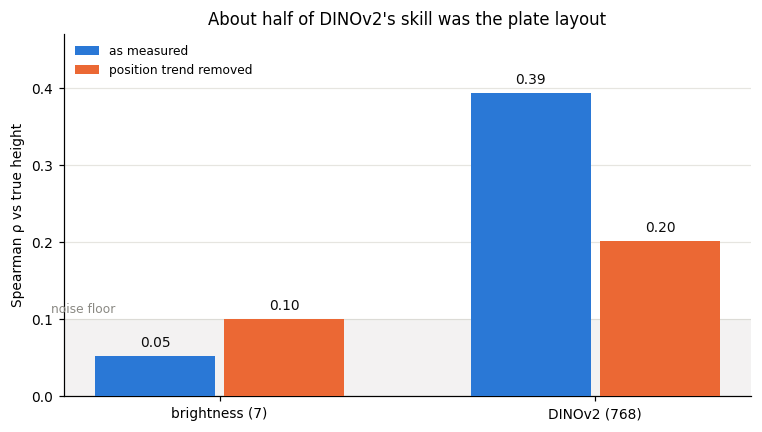

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
x = np.arange(2)
w = 0.32
bef = [gv("brightness", "corrected"), gv("DINOv2", "corrected")]
aft = [gv("brightness", "corrected, position removed"),
       gv("DINOv2", "corrected, position removed")]
ax.axhspan(0, NOISE_FLOOR, color="#8a8983", alpha=0.10, lw=0)
b1 = ax.bar(x - w/2 - 0.012, bef, w, color=BRIGHT, label="as measured", zorder=3)
b2 = ax.bar(x + w/2 + 0.012, aft, w, color=DINO,
            label="position trend removed", zorder=3)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f"{bar.get_height():.2f}", ha="center", fontsize=9,
                color="#0b0b0b", zorder=4)
ax.text(-0.45, NOISE_FLOOR + 0.008, "noise floor", fontsize=8, color="#8a8983")
ax.set_xticks(x)
ax.set_xticklabels(["brightness (7)", "DINOv2 (768)"])
ax.set_ylabel("Spearman ρ vs true height")
ax.set_ylim(0, 0.47)
ax.set_title("About half of DINOv2's skill was the plate layout")
ax.legend(fontsize=8, frameon=False, loc="upper left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e5e0", lw=0.8)
ax.set_axisbelow(True)
fig.tight_layout()

## 5. What a cell looks like, with the pad located from the photo alone

The outline is found by local contrast within the crop — no height data — so it
is available at deployment.

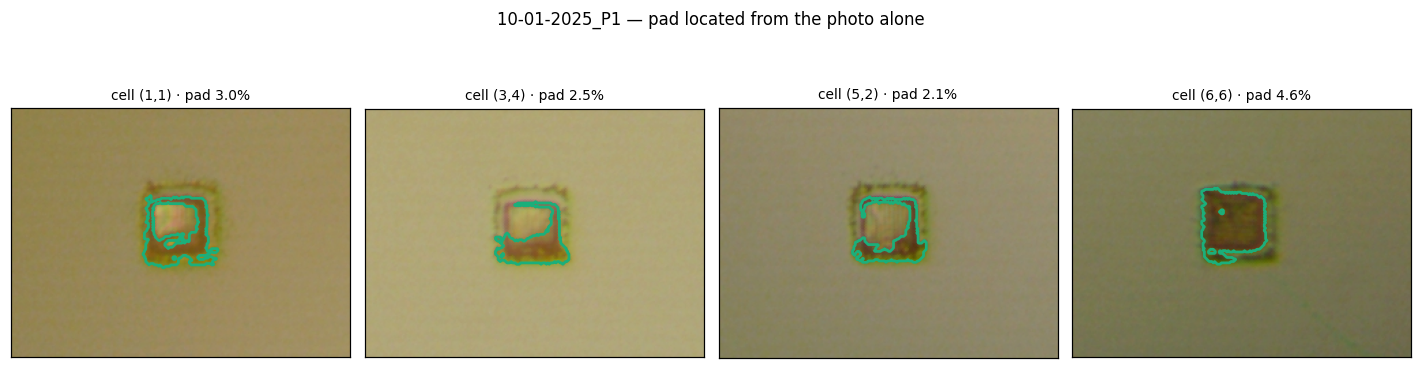

In [10]:
from Auto_OPDx.alignment.dataset import fit_cross_modal, solve_photo, solve_plate
from build_features import pad_mask_from_photo

stem = "10-01-2025_P1"
hm = solve_plate(REPO / "data" / "opdx" / f"{stem}.OPDx")
ph = solve_photo(next(q for q in (REPO / "data" / "rgb" / "img").iterdir()
                      if q.stem == stem))
cm = fit_cross_modal(hm, ph)
M, t = cm.affine[:2], cm.affine[2]
sx, sy = cm.um_per_px

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (r, c) in zip(axes, [(1, 1), (3, 4), (5, 2), (6, 6)]):
    px = np.linalg.inv(M.T) @ (hm.fit.predict((r, c))[0] - t)
    hw, hh = (267/2)/sx, (267/2)/sy
    xa, xb = int(px[0]-hw), int(px[0]+hw)
    ya, yb = int(px[1]-hh), int(px[1]+hh)
    patch = ph.img[max(0,ya):yb, max(0,xa):xb]
    mask = pad_mask_from_photo(patch)
    ax.imshow(patch)
    ax.contour(mask.astype(float), levels=[0.5], colors=[CTRL], linewidths=1.8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"cell ({r},{c}) · pad {mask.mean()*100:.1f}%", fontsize=9)
fig.suptitle(f"{stem} — pad located from the photo alone", y=1.02)
fig.tight_layout()

## Conclusion

| hypothesis | verdict |
|---|---|
| Diluted features | ❌ refuted — tightening makes it slightly worse |
| Crop tightness | ❌ refuted — tighter is not better on corrected labels |
| Label noise | ❌ refuted — all four variants within noise of each other |
| Absorption is the cue | ❌ refuted — substrate beside the pad predicts as well |
| Hand-crafted focus | ❌ refuted — ρ −0.09 |
| DINOv2's ρ 0.39 | ⚠️ about half was plate layout |
| A real signal exists | ✅ ρ ≈ 0.20, position-independent, structural |

**The negative result stands and is now much better supported.** A single
flat-lit photo carries some genuine thickness information, but it is weak, it is
not absorption, and it is not enough for absolute heights.

Two corrections this forces on the earlier write-up:

- "ranking works at ρ ≈ 0.42" should be **ρ ≈ 0.20** — half of it was positional.
- Any future evaluation **must** include the position control, or a model that
  has merely learned the illumination gradient will look like one that has
  learned thickness.

### Where to go next

Stop improving the features; give the camera a depth cue.

1. **Depth from focus, deliberately** — a z-stack on the motorised stage already
   being built for the mirrored view. No new hardware.
2. **Oblique illumination** — one LED at a known low angle; shadow length =
   height ÷ tan(angle). At 20° a 10 µm pad throws ~27 µm ≈ 25 px. Geometric, no
   model, ~$20.
3. **Reference patches** — needed for absolute scale, not sufficient alone: even
   with perfect µ and σ, ρ 0.20 gives R² ≈ 0.04.
4. **Per-formulation instead of per-cell** — between-plate SD (2.3 µm) is more
   than twice within-plate (1.0 µm), and it is closer to the lab's real question.
   Untested, and the cheapest remaining reframing.